In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Cargar dataset original
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/vehiculos_procesado_con_grupos.csv", sep=",").drop(
    ["fabricante", "modelo", "transmision", "traccion", "clase", "combustible", "consumo"], axis=1
)

# --- A) PROCESAR VARIABLES NUMÉRICAS ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_num = df[num_cols].copy()

# Rellenar valores nulos con el promedio de cada columna
for col in df_num.columns:
    df_num[col] = df_num[col].fillna(df_num[col].mean())

# Normalización MinMax (valores entre 0 y 1)
scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=num_cols)

# --- B) PROCESAR VARIABLES CATEGÓRICAS ---
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
# Convertir a variables dummy (One-Hot Encoding)
df_cat_encoded = pd.get_dummies(df[cat_cols], drop_first=False, dtype=int)

# --- C) CONCATENAR EN DF_PROCESADO ---
df_procesado = pd.concat([df_num_scaled, df_cat_encoded], axis=1)

print("=== 1. PREPROCESAMIENTO COMPLETADO ===")
print(f"Dimensiones finales del dataset procesado: {df_procesado.shape}")
df_procesado.head()

=== 1. PREPROCESAMIENTO COMPLETADO ===
Dimensiones finales del dataset procesado: (36791, 36)


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.000000,0.243590,0.142857,0.398014,0.331027,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
1,0.000000,0.461538,0.285714,0.527672,0.475113,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0.029412,0.243590,0.142857,0.424351,0.360294,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
3,0.029412,0.461538,0.285714,0.527672,0.475113,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
4,0.088235,0.410256,0.285714,0.424351,0.360294,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0


In [2]:
# Ajustar el modelo K-Means con 8 clústeres
kmeans_8 = KMeans(n_clusters=8, random_state=42, n_init=10)
df['cluster'] = kmeans_8.fit_transform(df_procesado).argmin(axis=1) # Asignación segura de clústeres

# Calcular centroides en el espacio transformado
centroides = kmeans_8.cluster_centers_

print("=== 2. RESUMEN DE CUALIDADES POR CLÚSTER (VARIABLES NUMÉRICAS) ===")
# Mostrar el promedio de las variables numéricas originales por cada clúster asignado
resumen_num = df.groupby('cluster')[num_cols].mean()
display(resumen_num)

print("\n=== MODA DE VARIABLES CATEGÓRICAS POR CLÚSTER ===")
resumen_cat = df.groupby('cluster')[cat_cols].agg(lambda x: x.mode()[0])
display(resumen_cat)

=== 2. RESUMEN DE CUALIDADES POR CLÚSTER (VARIABLES NUMÉRICAS) ===


,year,desplazamiento,cilindros,co2,consumo_litros_milla
cluster,,,,,
0,1998.528821,2.345201,4.430432,406.876555,0.172926
1,2003.358478,1.922741,4.044562,327.754130,0.139615
2,1997.860657,3.184894,5.595112,468.519901,0.199416
3,2000.216945,4.117672,6.581729,537.657591,0.228489
4,1997.064021,5.167600,8.031159,662.049423,0.281385
5,2004.016805,3.425859,6.193629,468.330734,0.199476
6,1999.383070,4.989295,7.677866,651.626738,0.275718
7,2003.704695,2.704675,4.940074,407.457375,0.172955



=== MODA DE VARIABLES CATEGÓRICAS POR CLÚSTER ===


,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo
cluster,,,,,,,
0,Coches pequeños,dos,Manual,Normal,pequeño,bajo,bajo
1,Coches pequeños,dos,Automatica,Normal,muy pequeño,muy bajo,muy bajo
2,Coches pequeños,dos,Automatica,Normal,mediano,moderado,moderado
3,Camionetas,dos,Automatica,Normal,grande,alto,alto
4,Furgoneta,dos,Automatica,Normal,muy grande,muy alto,muy alto
5,Coches pequeños,dos,Automatica,Premium,mediano,moderado,moderado
6,Camionetas,cuatro,Automatica,Normal,muy grande,muy alto,muy alto
7,Coches pequeños,dos,Automatica,Normal,pequeño,bajo,bajo


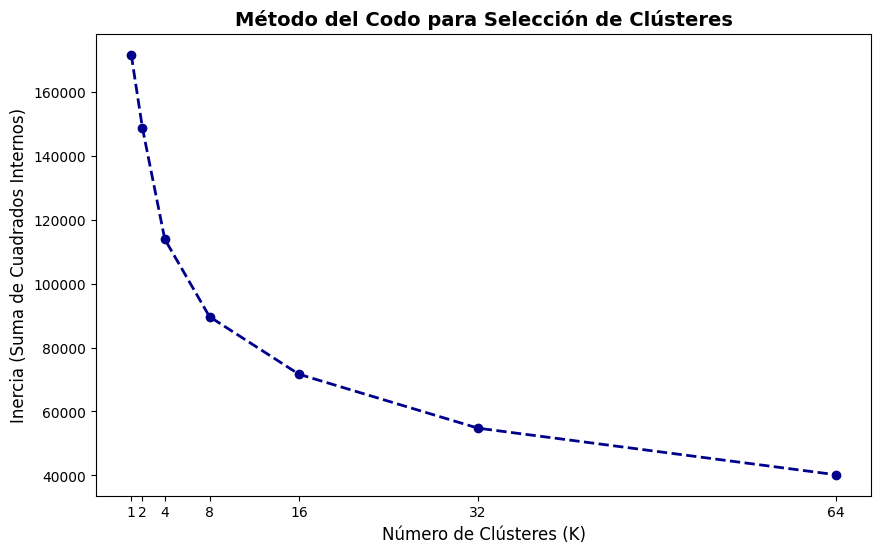

In [3]:
# Evaluamos la secuencia propuesta en la guía
secuencia_clusters = [1, 2, 4, 8, 16, 32, 64]
inercias = []

for k in secuencia_clusters:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_procesado)
    inercias.append(km.inertia_)

# Graficar la curva del codo
plt.figure(figsize=(10, 6))
plt.plot(secuencia_clusters, inercias, marker='o', linestyle='--', color='darkblue', linewidth=2)
plt.title('Método del Codo para Selección de Clústeres', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Inercia (Suma de Cuadrados Internos)', fontsize=12)
plt.xticks(secuencia_clusters)
plt.show()

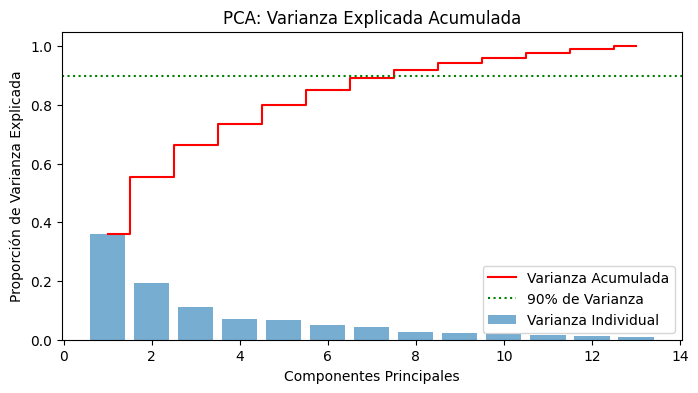

-> Se necesitan 8 componentes principales para capturar al menos el 90% de la información.


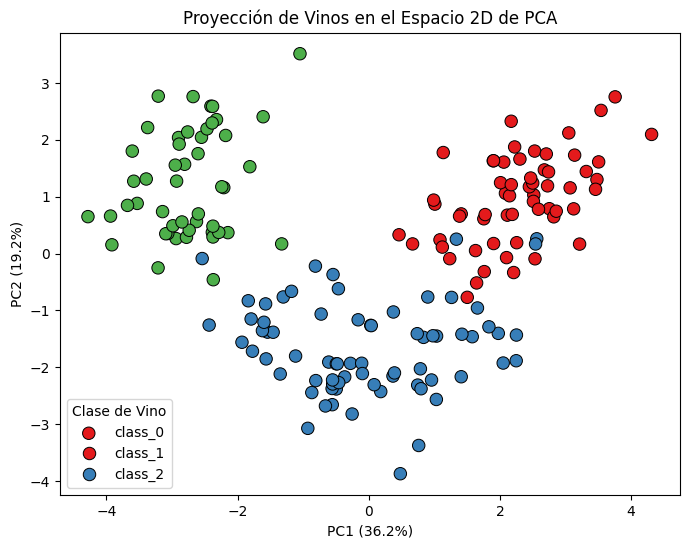


=== LOADINGS (PESOS) DE LAS VARIABLES EN PC1 Y PC2 ===


,PC1,PC2
flavanoids,0.422934,-0.003360
total_phenols,0.394661,0.065040
od280/od315_of_diluted_wines,0.376167,-0.164496
proanthocyanins,0.313429,0.039302
hue,0.296715,-0.279235
proline,0.286752,0.364903
alcohol,0.144329,0.483652
magnesium,0.141992,0.299634
ash,-0.002051,0.316069
color_intensity,-0.088617,0.529996


In [4]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Cargar dataset de vinos
dataset = load_wine()
X_wine = dataset.data
y_wine = dataset.target
features = dataset.feature_names

# PCA requiere estandarización obligatoria (media 0, varianza 1)
X_wine_scaled = StandardScaler().fit_transform(X_wine)

# Ajustar PCA con todos los componentes
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_wine_scaled)

# Calcular varianza explicada acumulada
var_explicada = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

# --- GRÁFICO 1: VARIANZA ACUMULADA ---
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(var_explicada)+1), var_explicada, alpha=0.6, align='center', label='Varianza Individual')
plt.step(range(1, len(var_acumulada)+1), var_acumulada, where='mid', color='red', label='Varianza Acumulada')
plt.axhline(y=0.90, color='g', linestyle=':', label='90% de Varianza')
plt.xlabel('Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.title('PCA: Varianza Explicada Acumulada')
plt.legend(loc='best')
plt.show()

# Determinar cuántos componentes se necesitan para el 90%
n_90 = np.argmax(var_acumulada >= 0.90) + 1
print(f"-> Se necesitan {n_90} componentes principales para capturar al menos el 90% de la información.")

# --- GRÁFICO 2: PROYECCIÓN 2D DE CLASES EN PCA ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_wine, palette='Set1', s=80, edgecolor='k')
plt.xlabel(f'PC1 ({var_explicada[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({var_explicada[1]*100:.1f}%)')
plt.title('Proyección de Vinos en el Espacio 2D de PCA')
plt.legend(title='Clase de Vino', labels=dataset.target_names)
plt.show()

# --- TABLA DE LOADINGS (INFLUENCIA QUÍMICA) ---
df_loadings = pd.DataFrame(pca.components_[:2], columns=features, index=['PC1', 'PC2']).T
print("\n=== LOADINGS (PESOS) DE LAS VARIABLES EN PC1 Y PC2 ===")
display(df_loadings.sort_values(by='PC1', ascending=False))

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


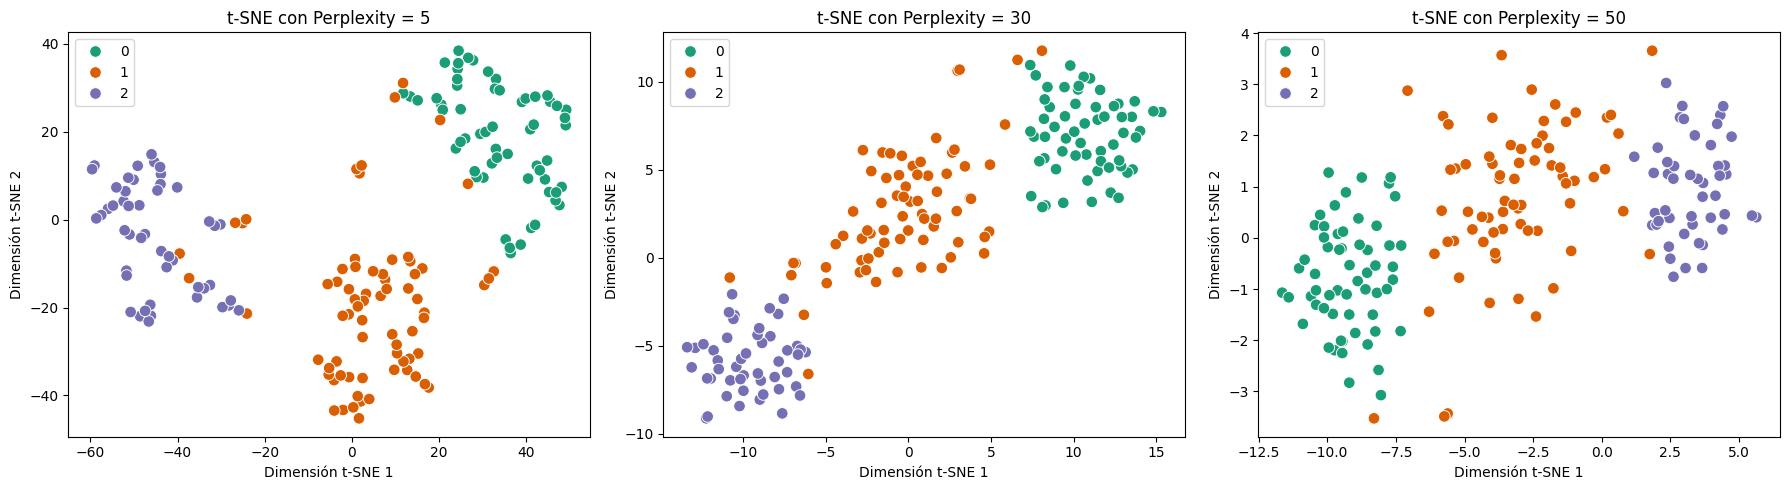

In [5]:
from sklearn.manifold import TSNE

perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, perp in enumerate(perplexities):
    # Ajustar t-SNE variando la perplejidad
    tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, random_state=42, n_iter=1000)
    X_tsne = tsne.fit_transform(X_wine_scaled)

    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_wine, palette='Dark2', s=70, ax=axes[i], edgecolor='w')
    axes[i].set_title(f't-SNE con Perplexity = {perp}')
    axes[i].set_xlabel('Dimensión t-SNE 1')
    axes[i].set_ylabel('Dimensión t-SNE 2')

plt.tight_layout()
plt.show()

Criterio,PCA (Principal Component Analysis),t-SNE (t-distributed Stochastic Neighbor Embedding)
Tipo de Método,Lineal. Maximiza la varianza global proyectando los datos mediante álgebra matricial.,"No Lineal. Probabilístico, preserva las distancias relativas locales (vecindades)."
Interpretabilidad,Alta. Mediante los loadings puedes saber con exactitud cuánto aporta cada variable química (ej: flavanoids o alcohol) a cada eje.,Baja. Las dimensiones resultantes no tienen un significado físico directo ni guardan una fórmula fija.
Efecto de Hiperparámetros,Ninguno. El resultado siempre es determinista y matemático.,Crítico. Modificar la perplexity (vecinos esperados) cambia drásticamente la forma del mapa.
Escenario de Uso Ideal,Reducción de dimensionalidad rápida previa a modelos de Machine Learning o para interpretar pesos estadísticos.,"Exploración inicial, inspección visual de agrupaciones difíciles y detección de patrones complejos en alta dimensión."